---
title: B528 - Assignment 1
author: Siddharth Rajesh
date: January 22, 2026
---

### Import python libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Function to load a matrix and calculate the correlation between column and generate correlation heatmap

In [2]:
def analyse_matrix(file_path: str = None, sep:str = None):
    matrix = pd.read_table(file_path, sep = sep)
    matrix = matrix.iloc[:, :-1]
    print('MATRIX')
    print(matrix.head())
    print(f"{'='*80}")
    print("Correlation Matrix")
    cor_matrix = matrix.iloc[:, 1:].corr()
    print(cor_matrix)
    
    print(f"{'='*80}")
    plt.figure(figsize=(12, 10))
    sns.heatmap(cor_matrix, cmap='coolwarm', center=0, square=True, 
                linewidths=0.5, annot=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
    plt.title('Correlation Matrix Heatmap')
    plt.tight_layout()
    plt.show()

### Loading Matrix 1 and analysing it

MATRIX
          miRNA       bladder  breast_cancer      cervical   head n neck  \
0  hsa-mir-3128      0.000000       0.000000      0.000000      0.517950   
1  hsa-mir-3658      0.000000       0.000000      0.000000      0.000000   
2   hsa-mir-217      8.155420      13.079703      1.292636      1.553849   
3    hsa-mir-22  63975.513995   67989.751326  33975.331973  38610.030611   
4   hsa-mir-612      0.107308       0.000000      0.430879      1.035899   

           KIRC          KIRP          LUAD           LUSC          PRAD  \
0      0.000000      0.000000      0.000000       0.000000      0.000000   
1      0.000000      0.000000      0.000000       0.000000      0.000000   
2     22.170186      8.636935     11.046939      13.892229     48.364237   
3  62109.621268  53628.721821  46660.234247  136844.266034  41627.489632   
4      0.000000      0.000000      0.000000       0.414693      0.300399   

           STAD           THCA          UCEC  
0      0.000000       0.000000  

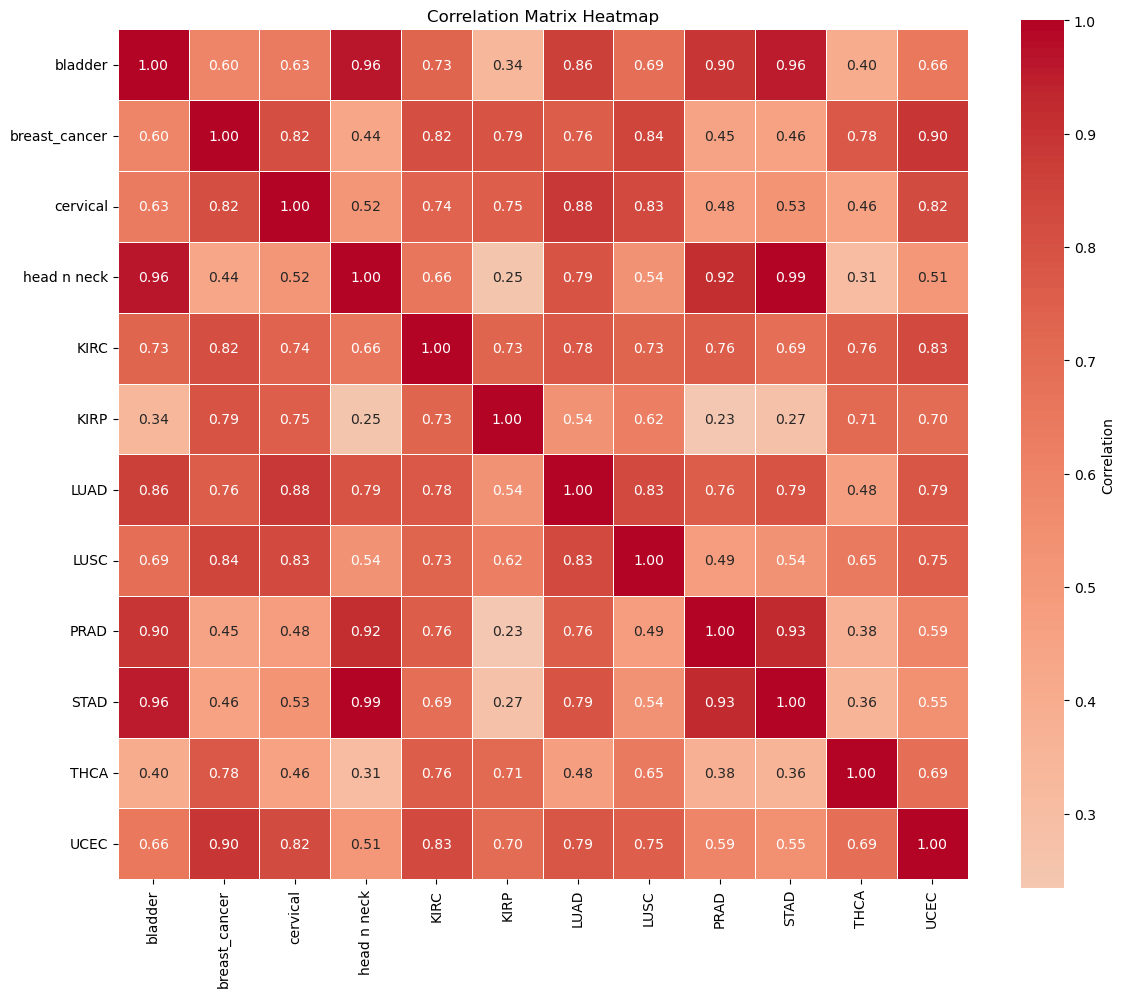

In [3]:
analyse_matrix('./data/matrix1.txt', sep='\t')

### Loading Matrix 2 and inspecting the data

MATRIX
          miRNA       bladder  breast_cancer      cervical    head n neck  \
0  hsa-mir-3128      0.000000       0.000000      0.118438       0.000000   
1  hsa-mir-3658      0.000000       0.000000      0.000000       0.000000   
2   hsa-mir-217      1.771178      25.559522     12.080640       7.977180   
3    hsa-mir-22  11618.929609   74313.291426  79215.956963  112291.438292   
4   hsa-mir-612      0.000000       0.226190      0.000000       0.000000   

           KIRC          KIRP          LUAD          LUSC          PRAD  \
0      0.000000      0.000000      0.000000      0.298948      0.000000   
1      0.000000      0.000000      0.000000      0.000000      0.000000   
2      1.456229    153.204962     26.312068     13.452661     13.037025   
3  63164.404335  68641.746313  36959.527811  99379.294202  18928.775005   
4      0.000000      0.113907      0.000000      0.000000      0.438219   

           STAD          THCA          UCEC  
0      0.000000      0.000000    

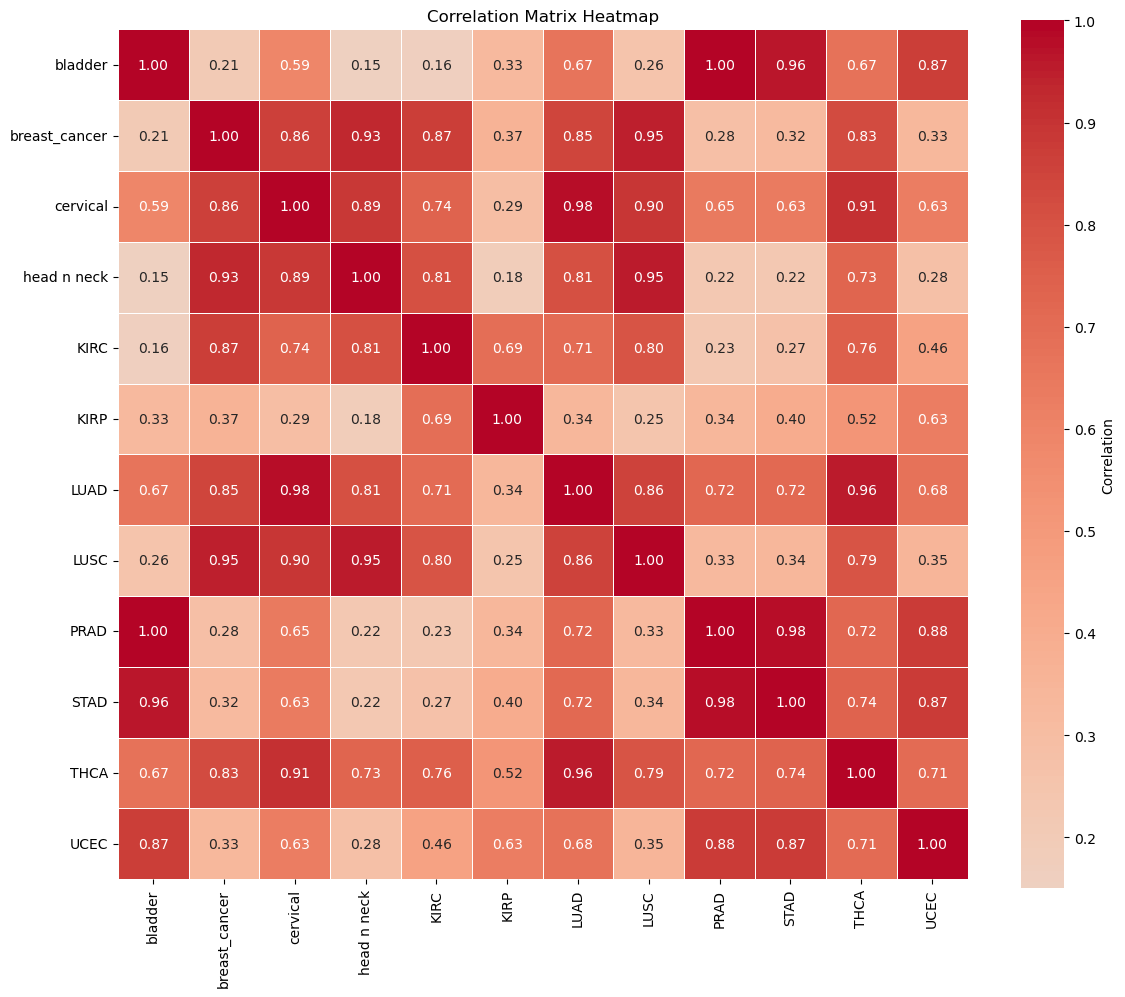

In [4]:
analyse_matrix('./data/matrix2.txt', sep='\t')

## Generating the correlation matrix between Matrix 1 and Matrix 2

In [5]:
matrix_1 = pd.read_table('./data/matrix1.txt', sep = '\t').iloc[:, :-1]
matrix_2 = pd.read_table('./data/matrix2.txt', sep = '\t').iloc[:, :-1]

cor_matrix_12 = matrix_1.iloc[:, 1:].apply(lambda column: matrix_2.iloc[:, 1:].corrwith(column))
print(cor_matrix_12)

                bladder  breast_cancer  cervical  head n neck      KIRC  \
bladder        0.877022       0.232461  0.286922     0.958048  0.521847   
breast_cancer  0.591539       0.914114  0.932566     0.458531  0.769313   
cervical       0.852700       0.740172  0.891789     0.788202  0.771102   
head n neck    0.543806       0.775685  0.917729     0.417116  0.644758   
KIRC           0.492852       0.868291  0.839229     0.370776  0.899953   
KIRP           0.380875       0.543641  0.322585     0.341237  0.811338   
LUAD           0.893146       0.756653  0.868459     0.841946  0.799384   
LUSC           0.668413       0.870571  0.914444     0.510254  0.695252   
PRAD           0.906358       0.296618  0.354723     0.974779  0.570265   
STAD           0.893024       0.346307  0.384025     0.945393  0.617022   
THCA           0.868608       0.795069  0.808879     0.825745  0.884852   
UCEC           0.840235       0.388011  0.389374     0.870231  0.748743   

                   KIRP 

### Heatmap for the correlation matrix between columns of Matrix 1 and Matrix 2

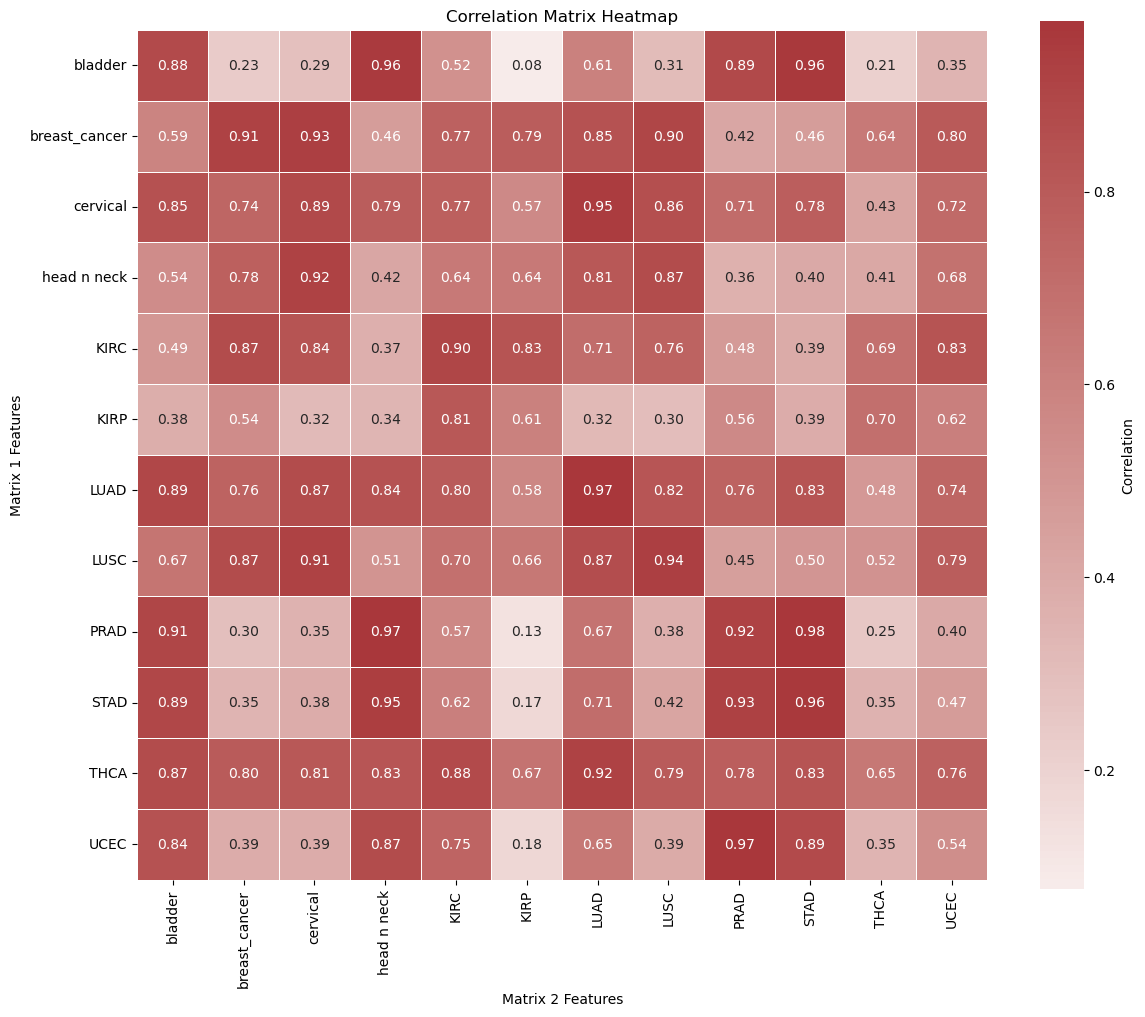

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(cor_matrix_12, cmap='vlag', center=0, square=True, 
            linewidths=0.5, annot=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.xlabel('Matrix 2 Features')
plt.ylabel('Matrix 1 Features')
plt.show()